<a href="https://colab.research.google.com/github/PavanRishi69/dataviz-exercises-pavan-rishi-gillella/blob/main/lecture04_exercise_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source:/content/gapminder.csv

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [ ]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


In [2]:
import plotly.express as px
import pandas as pd # pandas is implicitly used by plotly.express.data.gapminder, good practice to include

# Re-defining df and px to make the cell self-contained and resolve NameError
df = px.data.gapminder()

#Task 1
europe_df = df[(df['continent'] == 'Europe') & (df['year'].isin([2002, 2007]))].copy()

fig = px.scatter(
    europe_df,
    x="gdpPercap",
    y="lifeExp",
    color=europe_df['year'].astype(str),
    hover_name="country",
    log_x=True,  # <--- FIX: Rule 4 applied
    title="Consistent Gains in Health and Wealth Across Europe (2002–2007)", # <--- FIX: Rule 5 applied
    labels={"gdpPercap": "GDP per Capita ($)", "lifeExp": "Life Expectancy (Years)", "color": "Year"},
    template="plotly_white"
)

fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()

Between 2000 and 2007, most Asian countries showed steady progress in both economic performance and health outcomes. The upward movement suggests that rising incomes were often accompanied by longer life expectancy. However, the degree of improvement was not consistent across all nations. Some countries advanced more rapidly, while others showed slower growth. This highlights the presence of regional inequalities despite overall development.

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


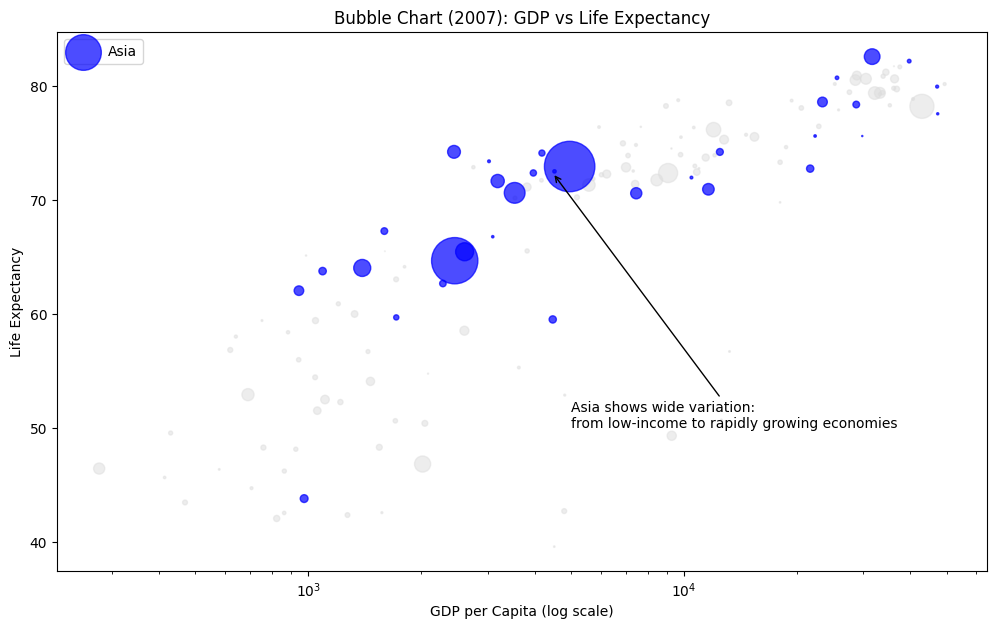

In [6]:
# Task 2
plt.figure(figsize=(12,7))

# Filter for 2007
df_2007 = df[df['year'] == 2007]

# Choose continent to highlight
highlight_continent = 'Asia'

# Plot all other continents in grey
others = df_2007[df_2007['continent'] != highlight_continent]
plt.scatter(others['gdpPercap'], others['lifeExp'],
            s=others['pop'] / 1000000,
            color='#DDDDDD', alpha=0.5)

# Plot highlighted continent
highlight = df_2007[df_2007['continent'] == highlight_continent]
plt.scatter(highlight['gdpPercap'], highlight['lifeExp'],
            s=highlight['pop'] / 1000000,
            color='blue', alpha=0.7, label=highlight_continent)

# Log scale for GDP
plt.xscale('log')

# Labels and title
plt.title("Bubble Chart (2007): GDP vs Life Expectancy")
plt.xlabel("GDP per Capita (log scale)")
plt.ylabel("Life Expectancy")

# Annotation (example insight)
plt.annotate("Asia shows wide variation:\nfrom low-income to rapidly growing economies",
             xy=(highlight['gdpPercap'].median(),
                 highlight['lifeExp'].median()),
             xytext=(5000, 50),
             arrowprops=dict(arrowstyle='->'))

plt.legend()
plt.show()

Asia holds a large share of the world’s population, yet countries differ greatly in income levels and health conditions. In contrast, Europe is more uniform, with most nations maintaining high GDP and long life expectancy. South America presents a balanced pattern, where life expectancy is relatively strong despite moderate income levels. This suggests that factors beyond wealth, such as healthcare systems, play an important role. Overall, global regions show distinct development patterns shaped by both economic and social factors.